In [ ]:
import pandas as pd

df = pd.read_csv("/content/Twitter_Data.csv")

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


,0
clean_text,4
category,7


In [ ]:
df.dropna(inplace=True)

In [ ]:
df['category'].value_counts()

,count
category,
1.0,72249
0.0,55211
-1.0,35509


In [ ]:
import re
import nltk

In [ ]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text

df['clean_text'] = df['clean_text'].apply(clean_text)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_text']

y = df['category']

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.7374363379763147
              precision    recall  f1-score   support

        -1.0       0.91      0.42      0.57      7152
         0.0       0.88      0.67      0.76     11067
         1.0       0.65      0.95      0.78     14375

    accuracy                           0.74     32594
   macro avg       0.81      0.68      0.70     32594
weighted avg       0.79      0.74      0.72     32594



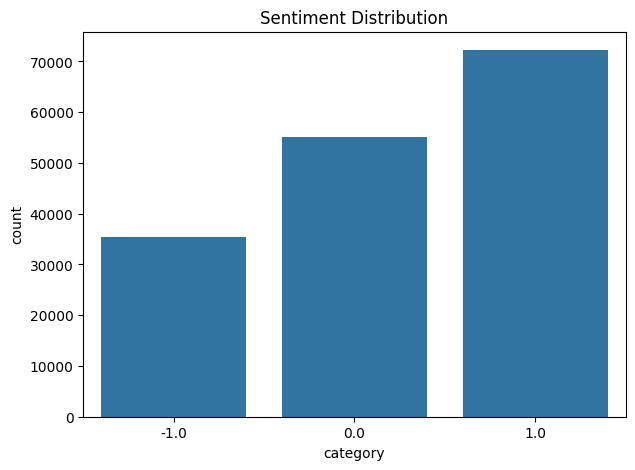

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    x='category',
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

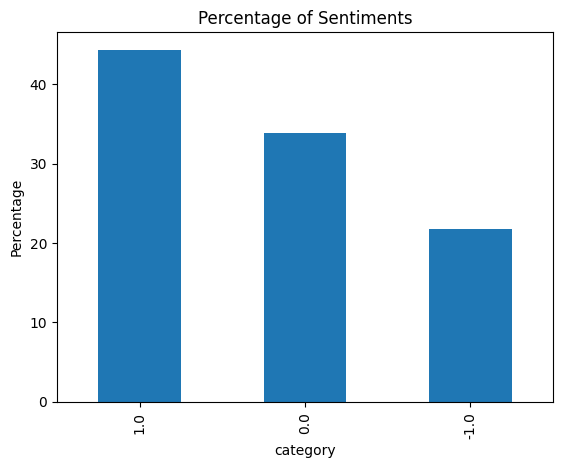

In [ ]:
sentiment_percent = (
    df['category']
    .value_counts(normalize=True)
    * 100
)

sentiment_percent.plot(
    kind='bar'
)

plt.title("Percentage of Sentiments")

plt.ylabel("Percentage")

plt.show()

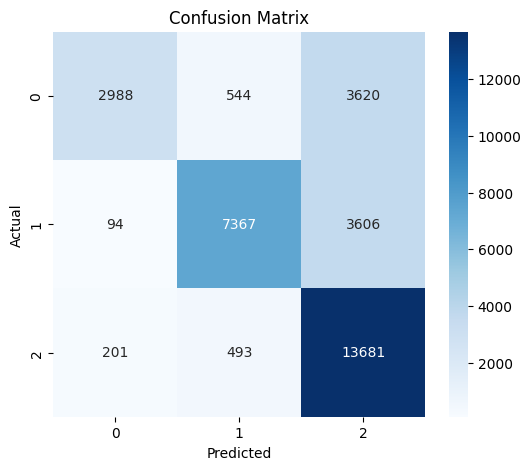

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# Recommendations

#1. Monitor customer feedback continuously using sentiment analysis.

#2. Address recurring negative sentiments to improve products and services.

#3. Utilize positive sentiments in marketing and promotional campaigns.

#4. Track sentiment trends over time to understand public opinion shifts.

#5. Implement advanced NLP models such as Support Vector Machines (SVM), Random Forest, or BERT to improve prediction accuracy.

#6. Combine sentiment analysis with topic modeling to identify key issues discussed by customers.